# RQ21 — Binding as a Scan-Level State Detector / Safety Veto

**Research question:** Can a complete ten-movement Binding scan identify a correct-prefix / binding-like mechanical state strongly enough to provide conservative backtracking evidence?

This RQ does not retrain MAIN v8 and does not restore Binding as the primary ranker. B01+B02 are development-only; B03 is held out from model and threshold selection.

The exact historical detector training script was not recovered. This notebook is a clean reimplementation of the frozen experimental formulation. Archived B03 results are shown only as reference and are not used for tuning.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import importlib
import sys
import numpy as np
import pandas as pd

MYDRIVE = Path('/content/drive/MyDrive')

result_candidates = [
    MYDRIVE / 'Padlock_Reproduction_v1' / 'results' / '21_RQ21_Binding_Safety_Veto',
    MYDRIVE / 'Padlock_Reproduction_v1' / 'Padlock_Reproduction_v1' / 'results' / '21_RQ21_Binding_Safety_Veto',
]
RESULT_DIR = next((p for p in result_candidates if p.exists()), None)
if RESULT_DIR is None:
    raise FileNotFoundError('Could not locate the RQ21 result folder.')

sys.path.insert(0, str(RESULT_DIR))
import RQ21_binding_safety_veto as rq21
rq21 = importlib.reload(rq21)

WORK_DIR = Path('/content/rq21_work')
print('RQ21 result folder:', RESULT_DIR)
print('Working folder:', WORK_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RQ21 result folder: /content/drive/MyDrive/Padlock_Reproduction_v1/results/21_RQ21_Binding_Safety_Veto
Working folder: /content/rq21_work


## Source-data check

The raw WAVs are read from the three complete Binding ZIP archives. Decision labels are read separately from `dataset/binding_scans/_progress`. This cell verifies the exact data sources before any feature extraction.

In [10]:
archive_check = rq21.archive_summary(MYDRIVE)
display(archive_check.style.format({'zip_mb': '{:.1f}'}))

assert archive_check['decision_jsons'].ge(120).all()
print('Binding source-data check passed.')

,batch,session,zip_mb,decision_jsons
0,B01,Binding_B01_3175,277.2,123
1,B02,Binding_B02_8642,279.3,122
2,B03,Binding_B03_0528,272.0,120


Binding source-data check passed.


## Build the persistent scan-feature cache

The first run copies each large ZIP to local Colab storage one at a time, extracts locally, computes one compact feature vector per ten-movement scan, saves the feature cache to Drive, and deletes the temporary raw extraction before moving to the next batch.

Expected final cache: **360 scans = 120 B01 + 120 B02 + 120 B03**.

In [11]:
rq21 = importlib.reload(rq21)

features = rq21.prepare_feature_cache(
    mydrive=MYDRIVE,
    result_dir=RESULT_DIR,
    work_dir=WORK_DIR,
    force=False,
)

print('Feature cache shape:', features.shape)
assert len(features) == 360

qc = (
    features.groupby(['batch', 'stage', 'direction', 'prefix_valid'], as_index=False)
    .size()
)
display(qc)
print('Scan-feature cache check passed.')

Reusing persistent RQ21 scan-feature cache
Feature cache shape: (360, 106)


,batch,stage,direction,prefix_valid,size
0,B01,1,CCW,0,27
1,B01,1,CCW,1,3
2,B01,1,CW,0,27
3,B01,1,CW,1,3
4,B01,2,CCW,0,27
5,B01,2,CCW,1,3
6,B01,2,CW,0,27
7,B01,2,CW,1,3
8,B02,1,CCW,0,27
9,B02,1,CCW,1,3


Scan-feature cache check passed.


## Fit on B01+B02 and score held-out B03

Four lightweight state models are fitted independently for Stage 1/2 and CCW/CW. B03 is not touched until feature selection and fitting are complete.

In [12]:
dev_scores, b03_scores, model_summary = rq21.fit_and_score(
    features=features,
    result_dir=RESULT_DIR,
)

auc_table = model_summary[['stage', 'direction', 'n_dev', 'n_test', 'b03_auc']].copy()
display(auc_table.style.format({'b03_auc': '{:.3f}'}))

,stage,direction,n_dev,n_test,b03_auc
0,1,CCW,60,30,0.728
1,1,CW,60,30,0.778
2,2,CCW,60,30,0.630
3,2,CW,60,30,0.519


## Archived reference — comparison only

These values were preserved in the project handoff before the dissertation reproduction. They are not targets for model tuning.

In [13]:
comparison = rq21.compare_archived_reference(
    model_summary=model_summary,
    result_dir=RESULT_DIR,
)

display(comparison.style.format({
    'b03_auc_reproduced': '{:.3f}',
    'b03_auc_archived': '{:.3f}',
    'difference': '{:+.3f}',
}))


,stage,direction,b03_auc_reproduced,b03_auc_archived,difference
0,1,CCW,0.728,0.850,-0.122
1,1,CW,0.778,0.840,-0.062
2,2,CCW,0.630,0.570,+0.060
3,2,CW,0.519,0.630,-0.111


## Freeze the conservative veto on B01+B02

The threshold is calibrated only on development data. The practical rule is chosen between `CCW_ONLY` and `BOTH_DIRECTIONS` using B01+B02 only, with zero correct-prefix false rejection given priority over wrong-prefix rejection.

In [14]:
rules = rq21.select_veto_rules(
    dev_scores=dev_scores,
    result_dir=RESULT_DIR,
)
display(rules)

b03_veto_detail, b03_veto_summary = rq21.evaluate_b03_veto(
    b03_scores=b03_scores,
    rules=rules,
    result_dir=RESULT_DIR,
)

display(
    b03_veto_summary.style.format({
        'correct_false_reject_rate': '{:.1%}',
        'wrong_reject_rate': '{:.1%}',
    })
)

,stage,selected_rule,development_correct_false_rejects,development_wrong_rejects
0,1,CCW_ONLY,0,45
1,2,CCW_ONLY,0,44


,stage,selected_rule,correct_n,correct_rejected,correct_false_reject_rate,wrong_n,wrong_rejected,wrong_reject_rate
0,1,CCW_ONLY,3,3,100.0%,27,23,85.2%
1,2,CCW_ONLY,3,1,33.3%,27,12,44.4%


## Final figures

The figures use the same simple blue-grey dissertation style as the later RQs: no large title, no heatmap, and no unnecessary diagnostic panels.

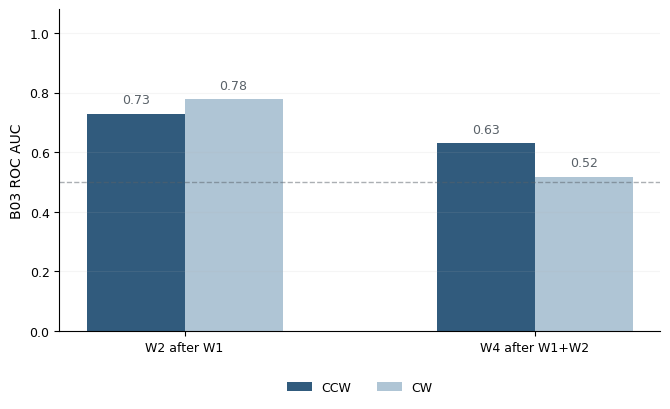

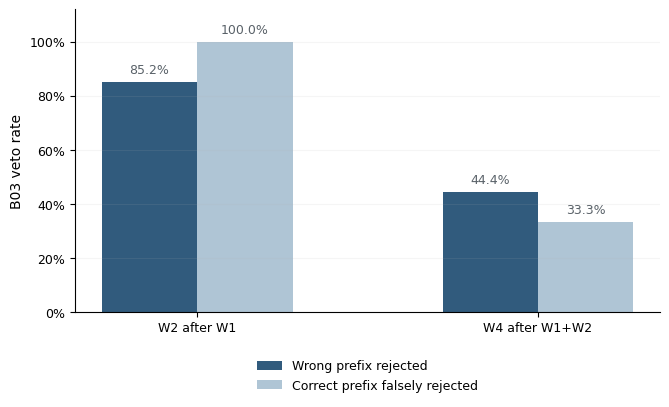

In [15]:
rq21.save_figures(
    model_summary=model_summary,
    veto_summary=b03_veto_summary,
    result_dir=RESULT_DIR,
)

## Save the RQ21 report and conclusion

In [16]:
rq21.write_report(
    model_summary=model_summary,
    veto_summary=b03_veto_summary,
    result_dir=RESULT_DIR,
)

print((RESULT_DIR / 'RQ21_Report.md').read_text(encoding='utf-8'))
print('RQ21 outputs saved.')

# RQ21 — Binding as a Scan-Level State Detector / Safety Veto

## Research question

Can the ten movements in a Binding scan identify whether the upstream prefix is mechanically binding-like strongly enough to provide conservative backtracking evidence?

## Reproduction status

The exact historical state-detector training script was not recovered. This notebook is therefore a clean reimplementation of the frozen experimental formulation rather than a bitwise replay. The experimental boundary is preserved: Binding B01 and B02 are development-only; Binding B03 is held out from fitting and threshold selection. Archived B03 values are retained separately as historical reference and are not used for tuning.

## B03 direction-specific discrimination

| Stage | CCW AUC | CW AUC |
|---|---:|---:|
| W2 after W1 | 0.728 | 0.778 |
| W4 after W1+W2 | 0.630 | 0.519 |

Archived reference: Stage 1 approximately 0.85 CCW / 0.84 CW; Stage 2 approximately 0.57 CCW / 0.63 CW.

## Conservative veto on B03